In [1]:
"""
Bursting requires a slow shutoff current and a fast activation current.

Fast activation = autapse

slow deactivation = coupled inhibitory interneuron.

"""




'\nBursting requires a slow shutoff current and a fast activation current.\n\nFast activation = autapse\n\nslow deactivation = coupled inhibitory interneuron.\n\n'

In [2]:
import sys
sys.path.append("..//")

from AQUA_general import AQUA
from batchAQUA_general import batchAQUA
from stimulus import *
from plotting_functions import *

#from AQUAmeetBrian import AQUAMeetBrian


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from brian2 import *

In [3]:
def visualise_connectivity(S):
    Ns = len(S.source)
    Nt = len(S.target)
    figure(figsize=(10, 4))
    subplot(121)
    plot(zeros(Ns), arange(Ns), 'ok', ms=10)
    plot(ones(Nt), arange(Nt), 'ok', ms=10)
    for i, j in zip(S.i, S.j):
        plot([0, 1], [i, j], '-k')
    xticks([0, 1], ['Source', 'Target'])
    ylabel('Neuron index')
    xlim(-0.1, 1.1)
    ylim(-1, max(Ns, Nt))
    subplot(122)
    plot(S.i, S.j, 'ok')
    xlim(-1, Ns)
    ylim(-1, Nt)
    xlabel('Source neuron index')
    ylabel('Target neuron index')


In [4]:
"""

Make use of the the meetBrian function for each population of neurons.

Can extract coupling parameters and decay constants from Deleuze et al. (2019)

"""


'\n\nMake use of the the meetBrian function for each population of neurons.\n\nCan extract coupling parameters and decay constants from Deleuze et al. (2019)\n\n'

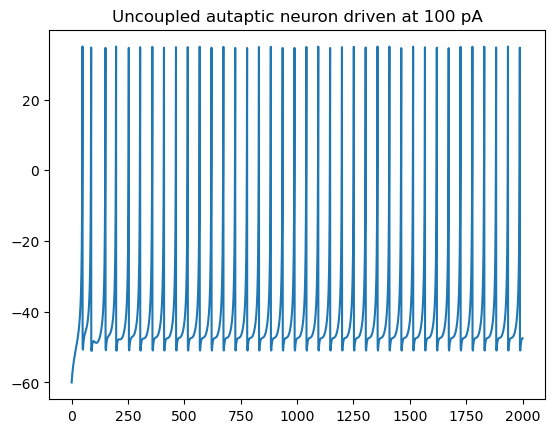

Firing Freqeuncy : 19.0 Hz


In [5]:
"""
Start with the uncoupled excitatory neuron.

"""


start_scope()

N_neurons = 1

RS = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.2, 'f': 150., 'tau': 2.0}

FS = {'name': 'FS', 'C': 20, 'k': 1, 'v_r': -55, 'v_t': -40, 'v_peak': 25,
     'a': 0.2, 'b': -2, 'c': -45, 'd': 150, 'e': 0.0, 'f': 0., 'tau': 0.0}


T = 2000  # ms
dt = 0.01
N_iter = int(T/dt)

I_h = 100
stimulus = TimedArray(I_h*np.ones(N_iter), dt = dt*ms)

x_ini = np.array([[-60, 0, 0]])
t_ini = 0.0

# create excitatory neuron
E_neuron = batchAQUA([RS])
E_neuron.Initialise(x_ini, t_ini)

E, E_aut = E_neuron.meetBrian(stimulus_name = stimulus)

# need to define I_inj
#E.I = I_h

# Get the behaviour of the uncoupled excitatory autapse
defaultclock.dt = dt*ms
M = StateMonitor(E, 'v', record = True)
spikemon = SpikeMonitor(E, record = True)
net = Network(E, E_aut, M , spikemon)

net.run(T*ms)

plt.plot(M.t/ms, M.v[0])
plt.title(f"Uncoupled autaptic neuron driven at {I_h} pA")
plt.show()

print(f"Firing Freqeuncy : {len(spikemon)/(T/1000)} Hz")


ALL FS!!!


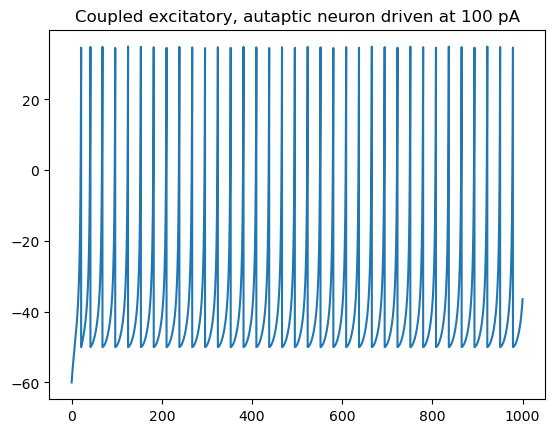

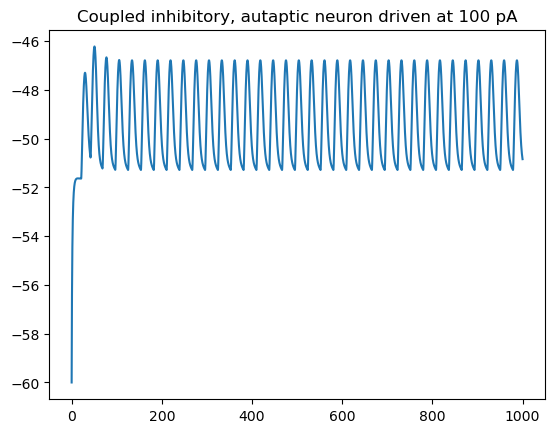

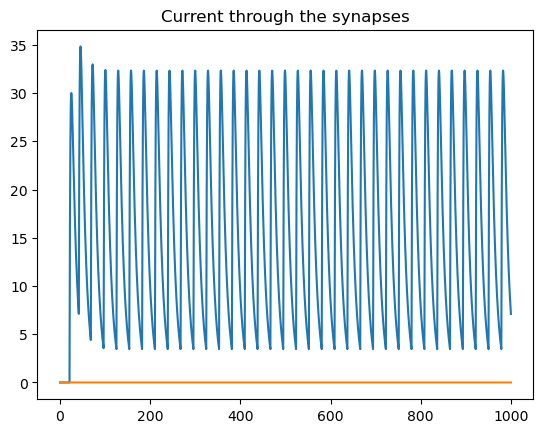

Firing Frequency : 35.0 Hz


In [17]:
"""
coupled E-I system!
"""

start_scope()

N_neurons = 1

RS = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.2, 'f': 0., 'tau': 2.0}

FS = {'name': 'FS', 'C': 20, 'k': 1, 'v_r': -55, 'v_t': -40, 'v_peak': 25,
     'a': 0.2, 'b': -2, 'c': -45, 'd': 150, 'e': 0.0, 'f': 0., 'tau': 0.0}


T = 1000  # ms
dt = 0.01
N_iter = int(T/dt)

I_e = 200
stimulus_e = TimedArray(I_e*np.ones(N_iter), dt = dt*ms)

I_i = 40.
stimulus_i = TimedArray(I_i*np.ones(N_iter), dt = dt*ms)


x_ini = np.array([[-60, 0, 0]])
t_ini = 0.0


# create excitatory neuron
E_neuron = batchAQUA([RS])
E_neuron.Initialise(x_ini, t_ini)

E, E_aut = E_neuron.meetBrian(stimulus_name = stimulus_e)     # has non-zero autapse

# create inhibitory neuron
I_neuron = batchAQUA([FS])
I_neuron.Initialise(x_ini, t_ini)

I, I_aut = I_neuron.meetBrian(stimulus_name = stimulus_i)     # has a zero autapse

# need to define I_inj
#E.I = I_h
#I.I = 60        # no drive to inhibitory


"""
Synapse values are taken from Deleuze et al. (2019) for PV->PN or PV autapses
and Yin et al. (2018) for PN autapses.
"""

syn_eq = """
dI_syn/dt = -(I_syn/t_syn)/ms : 1 (clock-driven)
t_syn : 1
w_syn : 1
g_total_post = I_syn : 1 (summed)
"""

syn_biexp = '''
dI_syn/dt = ((t_syn2/t_syn1) ** (t_syn1 / (t_syn2 - t_syn1)) * x_syn - I_syn) / t_syn1 / ms : 1
dx_syn/dt = -x_syn/t_syn2/ms : 1
t_syn1 : 1
t_syn2 : 1
w_syn : 1
g_total_post = I_syn : 1 (summed)
'''

syn_on_pre = '''
I_syn += w_syn
'''

syn_on_pre_biexp = '''
x_syn += w_syn
'''

# create a synapse from exc. to inh.
syn_pc_pv = Synapses(E, I, 
                model = syn_biexp,
                on_pre = syn_on_pre_biexp)
syn_pc_pv.connect(j = 'i')  # one-to-one connection

# create the synapse from inh. to exc.
syn_pv_pc = Synapses(I, E,
                model = syn_biexp,
                on_pre = syn_on_pre_biexp)
syn_pv_pc.connect(j = 'i')  # one-to-one connection

# set synapse variables
syn_pc_pv.I_syn = 0.
syn_pc_pv.x_syn = 0.
#syn_pc_pv.t_syn = 5.        # time constant of exc. synapse
syn_pc_pv.t_syn1 = 2.       # rise time
syn_pc_pv.t_syn2 = 10       # decay time
syn_pc_pv.w_syn = 30.       # strength of excitatory synapse [pA]

syn_pv_pc.I_syn = 0.  
syn_pv_pc.x_syn = 0.    
syn_pv_pc.t_syn1 = 20.      # rise time
syn_pv_pc.t_syn2 = 100.     # decay time
syn_pv_pc.w_syn = -150      # strength of PV synapse [pA]   


# Get the behaviour of the excitatory autapse
defaultclock.dt = dt*ms
M_e = StateMonitor(E, 'v', record = True)
spikemon_e = SpikeMonitor(E, record = True)

M_i = StateMonitor(I, 'v', record = True)
spikemon_i = SpikeMonitor(I, record = True)

M_syn_e = StateMonitor(syn_pc_pv, 'I_syn', record = True)
M_syn_i = StateMonitor(syn_pv_pc, 'I_syn', record = True)

# create a network of neurons
net = Network(E, E_aut, I, I_aut, syn_pc_pv, syn_pv_pc, M_e , M_i, spikemon_e, spikemon_i, M_syn_e, M_syn_i)

net.run(T*ms)

plt.plot(M_e.t/ms, M_e.v[0])
plt.title(f"Coupled excitatory, autaptic neuron driven at {I_h} pA")
plt.show()

plt.plot(M_i.t/ms, M_i.v[0])
plt.title(f"Coupled inhibitory, autaptic neuron driven at {I_h} pA")
plt.show()


plt.plot(M_syn_e.t/ms, M_syn_e.I_syn[0], label = 'excitatory synapse')
plt.plot(M_syn_i.t/ms, M_syn_i.I_syn[0], label = 'inhibitory synapse')
plt.title(f"Current through the synapses")
plt.show()

print(f"Firing Frequency : {len(spikemon_e)/(T/1000)} Hz")